In [49]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
ecoli = pd.read_csv('../ncbi_562_data.csv')
salmonella = pd.read_csv('../ncbi_590_data.csv')

C:\Users\brhz8b\AppData\Local\Temp\ipykernel_22584\600411681.py:6: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  salmonella = pd.read_csv('../ncbi_590_data.csv')


In [50]:
ecoli = ecoli[ecoli['is_usa_based'] == 1]
salmonella = salmonella[salmonella['is_usa_based'] == 1]

In [51]:
ecoli['submitter'].value_counts()

submitter
CDC                                                                                                                       47687
FDA                                                                                                                       21532
National Center for Biotechnology Information                                                                              9305
FDA/CFSAN                                                                                                                  8717
FDA Center for Food Safety and Applied Nutrition                                                                           4216
Vet-LIRN-CVM-FDA                                                                                                           2319
Walter Reed Army Institute of Research                                                                                     2234
US Food and Drug Administration                                                               

In [52]:
#if sumbitter is National Center for Biotechnology Information, replace with NCBI
ecoli['submitter'] = ecoli['submitter'].replace('National Center for Biotechnology Information', 'NCBI')
salmonella['submitter'] = salmonella['submitter'].replace('National Center for Biotechnology Information', 'NCBI')
ecoli['submitter'] = ecoli['submitter'].replace('FDA Center for Food Safety and Applied Nutrition', 'FDA/CFSAN')
salmonella['submitter'] = salmonella['submitter'].replace('FDA Center for Food Safety and Applied Nutrition', 'FDA/CFSAN')
ecoli['submitter'] = ecoli['submitter'].replace('FDA/CFSAN', 'FDA')
salmonella['submitter'] = salmonella['submitter'].replace('FDA/CFSAN', 'FDA')
ecoli['submitter'] = ecoli['submitter'].replace('US Food and Drug Administration', 'FDA')
salmonella['submitter'] = salmonella['submitter'].replace('US Food and Drug Administration', 'FDA')
ecoli['submitter'] = ecoli['submitter'].replace('CDC Prevention Epicenter Program', 'CDC')
salmonella['submitter'] = salmonella['submitter'].replace('CDC Prevention Epicenter Program', 'CDC')
ecoli['submitter'] = ecoli['submitter'].replace('Enteric Diseases Laboratory Branch, Centers for Disease Control and Prevention', 'CDC')
salmonella['submitter'] = salmonella['submitter'].replace('Enteric Diseases Laboratory Branch, Centers for Disease Control and Prevention', 'CDC')
ecoli['submitter'] = ecoli['submitter'].replace('Centers for Disease Control and Prevention. Division of Healthcare Quality Promotion', 'CDC')
salmonella['submitter'] = salmonella['submitter'].replace('Centers for Disease Control and Prevention. Division of Healthcare Quality Promotion', 'CDC')
ecoli['submitter'].value_counts()


submitter
CDC                                                                                                                       49920
FDA                                                                                                                       36634
NCBI                                                                                                                       9305
Vet-LIRN-CVM-FDA                                                                                                           2319
Walter Reed Army Institute of Research                                                                                     2234
University of Florida                                                                                                       810
University of Washington                                                                                                    810
Massachusetts Institute of Technology                                                         

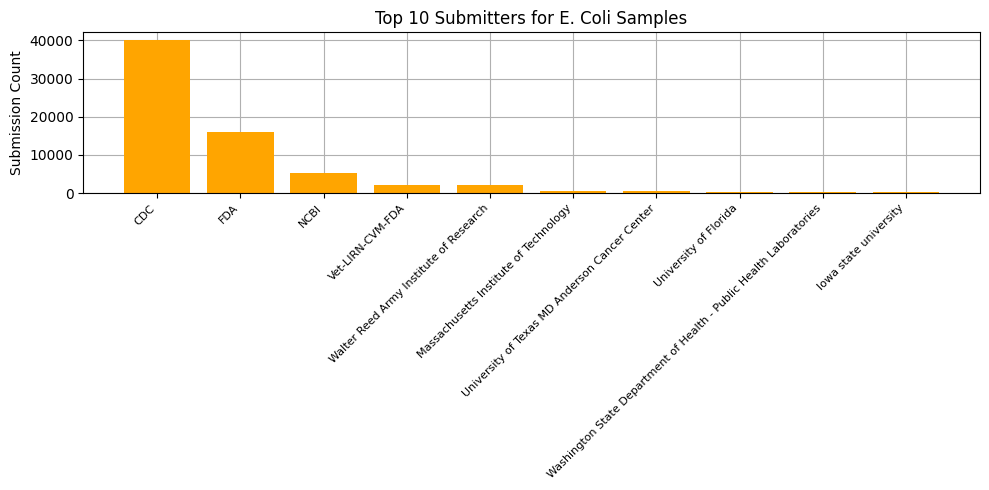

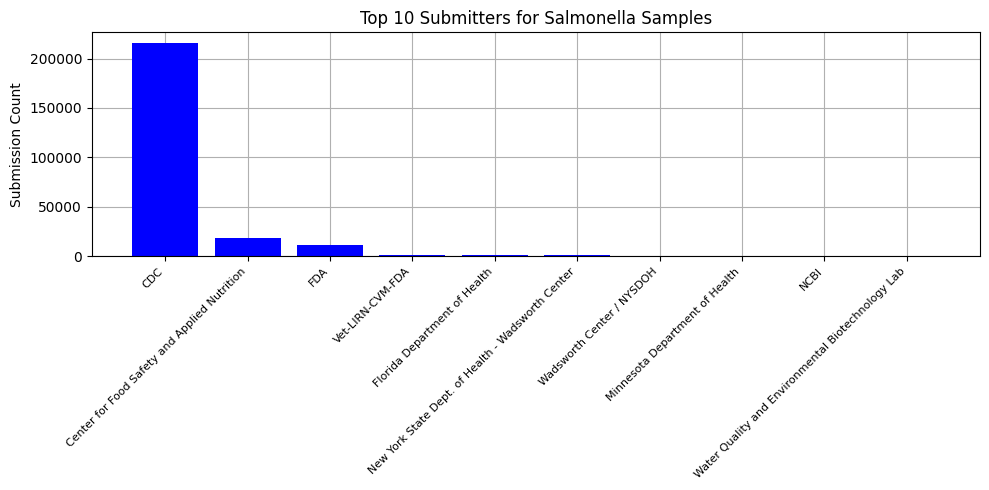

In [59]:
#make a bar chart of the top 10 submitters for each dataset
ecoli_submitters = ecoli['submitter'].value_counts().head(10)
salmonella_submitters = salmonella['submitter'].value_counts().head(10)
#make a bar chart of the top 10 submitters for each dataset
plt.figure(figsize=(10, 5))
plt.bar(ecoli_submitters.index, ecoli_submitters.values, color='orange', label='E. Coli')
plt.title('Top 10 Submitters for E. Coli Samples')
plt.ylabel('Submission Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.gca().set_axisbelow(True)
plt.grid(axis='both')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(salmonella_submitters.index, salmonella_submitters.values, color='blue', label='Salmonella')
plt.title('Top 10 Submitters for Salmonella Samples')
plt.ylabel('Submission Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.gca().set_axisbelow(True)
plt.grid(axis='both')
plt.tight_layout()
plt.show()


In [54]:

ecoli['collection_year'] = pd.to_numeric(ecoli['collection_year'], errors='coerce')
ecoli = ecoli[ecoli['collection_year'] >= 1971]
ecoli = ecoli[ecoli['month'].notna()]
ecoli['collection_year'] = ecoli['collection_year'].astype(str)
ecoli['collection_year'] = ecoli['collection_year'].str[:4]
ecoli['month'] = ecoli['month'].astype(int)
ecoli['month'] = ecoli['month'].apply(lambda x: f"{x:02d}")
ecoli['year_and_month'] = ecoli['collection_year'] + '-' + ecoli['month']

salmonella = salmonella[salmonella['is_usa_based'] == 1]
salmonella['collection_year'] = pd.to_numeric(salmonella['collection_year'], errors='coerce')
salmonella = salmonella[salmonella['collection_year'] >= 1971]
salmonella = salmonella[salmonella['month'].notna()]
salmonella['collection_year'] = salmonella['collection_year'].astype(str)
salmonella['collection_year'] = salmonella['collection_year'].str[:4]
salmonella['month'] = salmonella['month'].astype(int)
salmonella['month'] = salmonella['month'].apply(lambda x: f"{x:02d}")
salmonella['year_and_month'] = salmonella['collection_year'] + '-' + salmonella['month']

<Axes: xlabel='submitter'>

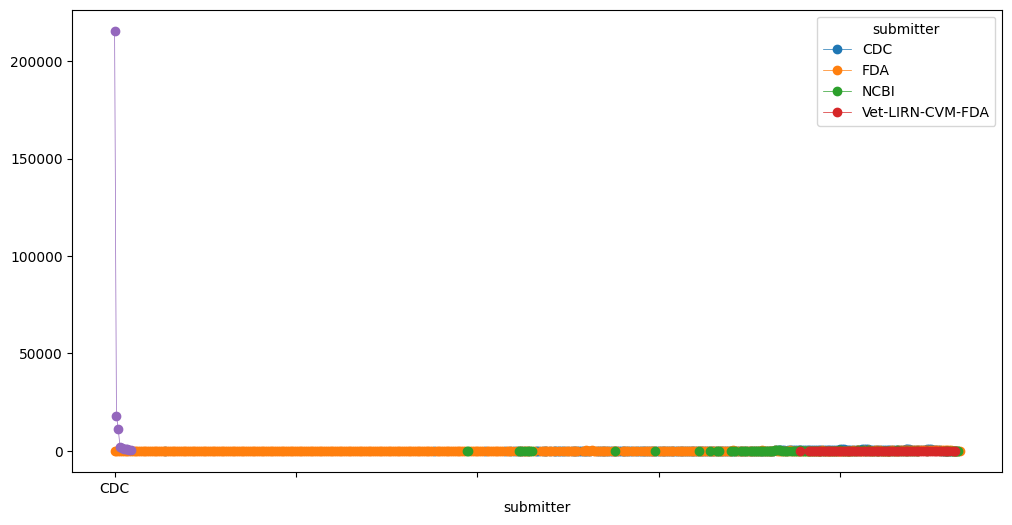

In [ ]:
#make a line plot of the number of submissions per year for the top 4 submitters. Use year_and_month as the x-axis
ecoli_top_submitters = ecoli['submitter'].value_counts().head(4).index
salmonella_top_submitters = salmonella['submitter'].value_counts().head(4).index
ecoli_top_submitters = ecoli[ecoli['submitter'].isin(ecoli_top_submitters)]
salmonella_top_submitters = salmonella[salmonella['submitter'].isin(salmonella_top_submitters)]
ecoli_top_submitters = ecoli_top_submitters.groupby(['year_and_month', 'submitter']).size().unstack()
salmonella_top_submitters = salmonella_top_submitters.groupby(['year_and_month', 'submitter']).size().unstack()
ecoli_top_submitters.plot(kind='line', marker='o', linewidth=0.5, figsize=(12, 6))
salmonella_submitters.plot(kind='line', marker='o', linewidth=0.5, figsize=(12, 6))




NameError: name 'year_month_counts1' is not defined

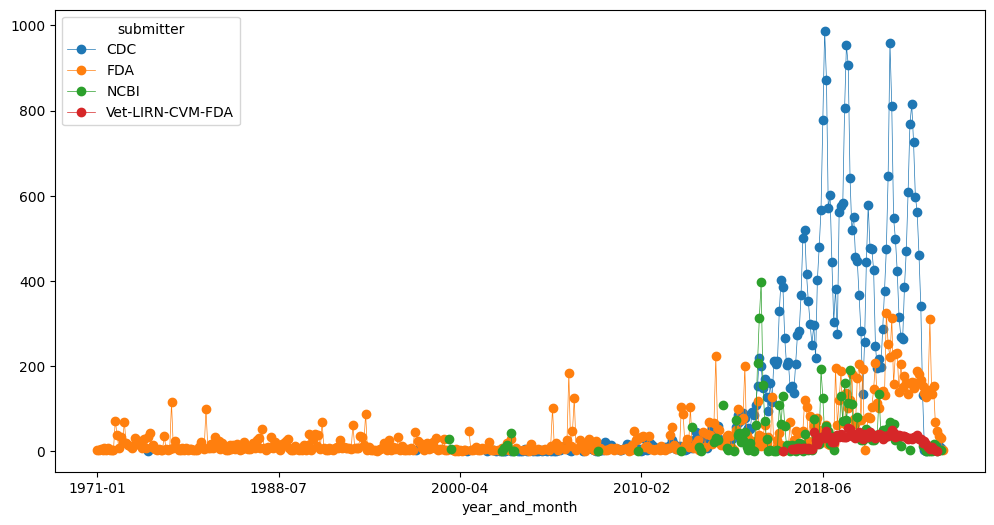

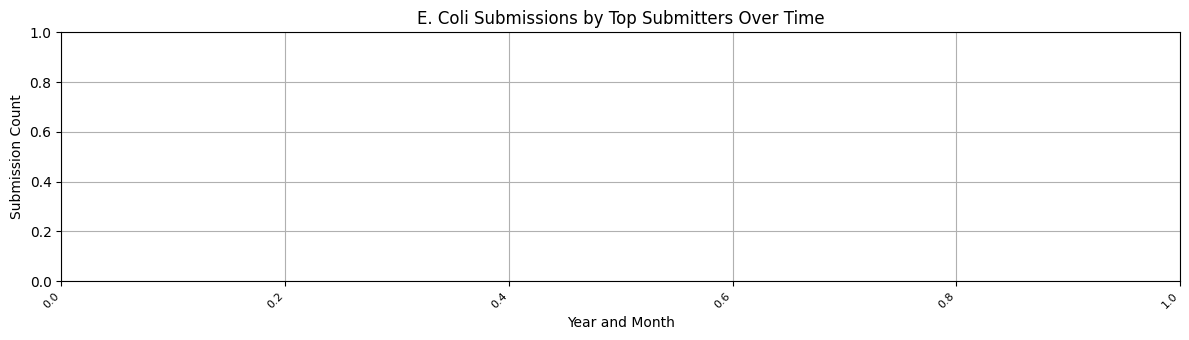

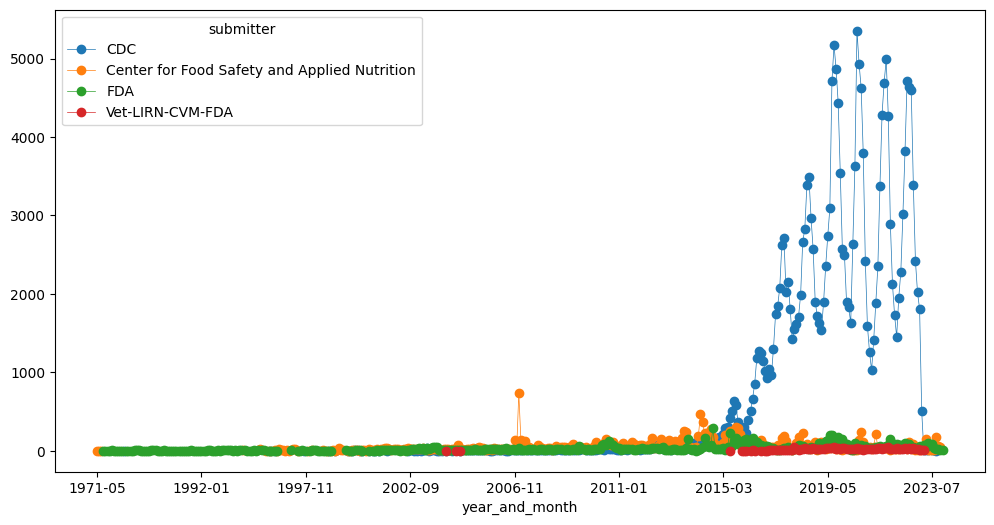

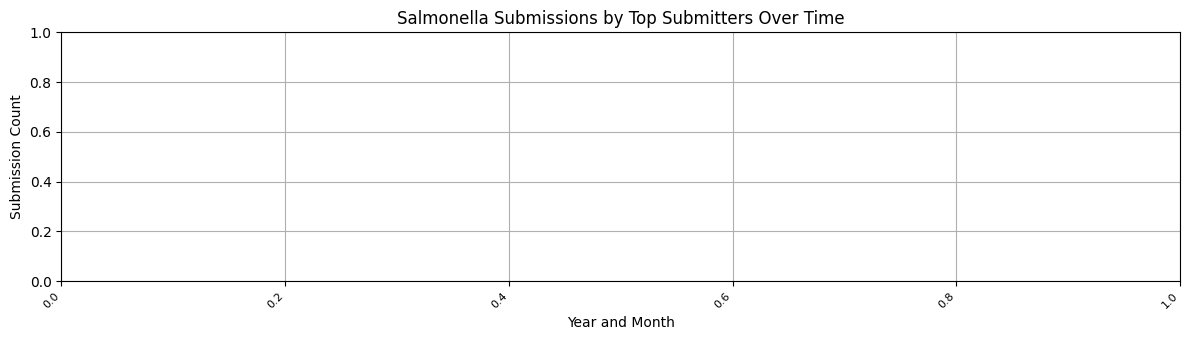

In [63]:

ecoli_top_submitters.plot(kind='line', marker='o', linewidth=0.5, figsize=(12, 6))
plt.figure(figsize=(12, 3.5))
plt.title('E. Coli Submissions by Top Submitters Over Time')
plt.xlabel('Year and Month')
plt.ylabel('Submission Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.gca().set_axisbelow(True)
plt.grid(axis='both')
plt.tight_layout()
salmonella_top_submitters.plot(kind='line', marker='o', linewidth=0.5, figsize=(12, 6))
plt.figure(figsize=(12, 3.5))
plt.title('Salmonella Submissions by Top Submitters Over Time')
plt.xlabel('Year and Month')
plt.ylabel('Submission Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.gca().set_axisbelow(True)
plt.grid(axis='both')
plt.tight_layout()

